In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score,roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
df = pd.read_excel('/content/unijos_student_housing_100_listings (1).xlsx')
df['expensive'] = np.where(df['Price (₦)'] >170000, 1, 0)
df.head()

,Lodge/Accommodation Name,Location,House Type,Has Light,Has Water,Price (₦),Furnished,Yearly or Monthly,Distance in km,Distance in Walking (mins),expensive
0,Naraguta Hostel Block A-D,Naraguta Campus (On-Campus),Hostel Room (Shared),Yes(Grid+Generator),Yes (Running Water),60500,Semi-Furnished (Bed/Wardrobe),Yearly,0.27,3,0
1,Zion Hostel (Female),Naraguta Campus (On-Campus),Hostel Room (Shared),Yes (Grid + Generator),Yes (Borehole),60500,Semi-Furnished (Bed/Wardrobe),Yearly,0.02,2,0
2,Abuja Hostel,Naraguta Campus (On-Campus),Hostel Room (Shared),Yes (Grid + Generator),Yes (Borehole),30500,Semi-Furnished (Bed/Wardrobe),Yearly,0.02,2,0
3,Student Village Hostel,Naraguta Campus (On-Campus),Hostel Room (Shared),Yes (Grid + Generator),Yes (Borehole),30500,Semi-Furnished (Bed/Wardrobe),Yearly,0.26,3,0
4,Postgraduate (PG) Hostel,Naraguta Campus (On-Campus),Hostel Room (Shared),Yes (Grid + Generator),Yes (Running Water),110500,Semi-Furnished (Bed/Wardrobe),Yearly,0.06,2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Lodge/Accommodation Name    100 non-null    object 
 1   Location                    100 non-null    object 
 2   House Type                  100 non-null    object 
 3   Has Light                   100 non-null    object 
 4   Has Water                   100 non-null    object 
 5   Price (₦)                   100 non-null    int64  
 6   Furnished                   100 non-null    object 
 7   Yearly or Monthly           100 non-null    object 
 8   Distance in km              100 non-null    float64
 9   Distance in Walking (mins)  100 non-null    int64  
 10  expensive                   100 non-null    int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 8.7+ KB


In [8]:
df.tail()

,Lodge/Accommodation Name,Location,House Type,Has Light,Has Water,Price (₦),Furnished,Yearly or Monthly,Distance in km,Distance in Walking (mins),expensive
95,Highland Complex,Naraguta Off-Campus,1-Bedroom Flat,Yes (Prepaid Meter),Yes (Borehole),220000,Unfurnished,Yearly,0.50,6,1
96,Grace Villa,Farin Gada,Self-Contain,Yes (Prepaid Meter),No (Well Water),270000,Semi-Furnished,Yearly,0.96,11,1
97,Apex Court,Bauchi Road / Ring Road,Single Room,No (Frequent Outages),Yes (Borehole),250000,Unfurnished,Yearly,1.44,17,1
98,Sunnyside Hub,Angwan Rukuba,Single Room,Yes (Grid Only),Yes (Borehole),145000,Unfurnished,Yearly,2.18,26,0
99,Peace Complex,Bauchi Road / Ring Road,Single Room,No (Frequent Outages),No (Well Water),140000,Unfurnished,Yearly,1.26,15,0


In [9]:
x=df.drop(['expensive','Price (₦)','Lodge/Accommodation Name'],axis=1)
y=df['expensive']

In [10]:
#split the data
numeric_cols=x.select_dtypes(include=np.number).columns
categorical_cols=x.select_dtypes('object').columns

In [11]:
#train the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
from sklearn.pipeline import Pipeline

#preprocessing the data
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('numeric', numeric_pipe, numeric_cols), ('categorical', categorical_pipe, categorical_cols)])
model = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000,class_weight='balanced',solver='lbfgs',C=0.1,random_state=42))])
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Distance in km', 'Distance in Walking (mins)'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'House Type', 'Has Light', 'Has Water', 'Furnished',
       'Yearly or Monthly'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [13]:
y_pred=model.predict(x_test)
y_pred

array([1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [14]:
proba=model.predict_proba(x_test)
proba

array([[0.48917262, 0.51082738],
       [0.30510455, 0.69489545],
       [0.33612296, 0.66387704],
       [0.48666525, 0.51333475],
       [0.56409882, 0.43590118],
       [0.49990708, 0.50009292],
       [0.53224795, 0.46775205],
       [0.42327742, 0.57672258],
       [0.5084014 , 0.4915986 ],
       [0.52922941, 0.47077059],
       [0.49133335, 0.50866665],
       [0.29727539, 0.70272461],
       [0.33748662, 0.66251338],
       [0.29381427, 0.70618573],
       [0.47858984, 0.52141016],
       [0.24123592, 0.75876408],
       [0.51310296, 0.48689704],
       [0.43577484, 0.56422516],
       [0.48921349, 0.51078651],
       [0.48489632, 0.51510368]])

In [15]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.87      0.81      0.84        16

    accuracy                           0.75        20
   macro avg       0.63      0.66      0.64        20
weighted avg       0.77      0.75      0.76        20



In [16]:
print("accuracy:",accuracy_score(y_test,y_pred)*100)
print("roc_auc_score:",roc_auc_score(y_test,proba[:,1]))
cm=confusion_matrix(y_test,y_pred)
print(cm)

accuracy: 75.0
roc_auc_score: 0.609375
[[ 2  2]
 [ 3 13]]


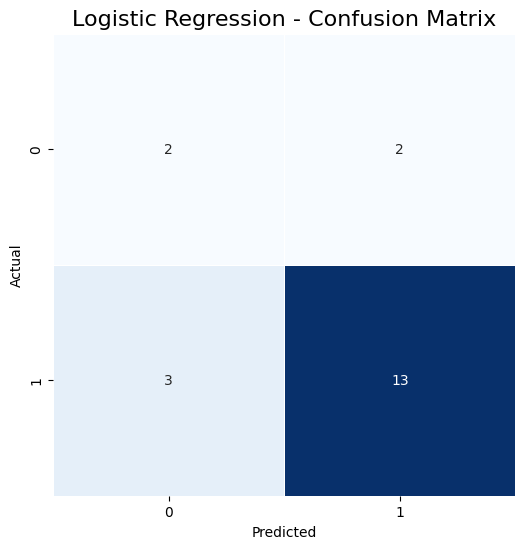

In [17]:
plt.figure(figsize=(10,6))
# Cleaned up duplicate 'cm' and 'annot' parameters to fix syntax and keyword issues
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=.5, square=True, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
alt_sample_title='Logistic Regression - Confusion Matrix'
plt.title(alt_sample_title, size=16)
plt.show()

In [18]:
# Create a DataFrame with a new listing containing all expected training features
new = pd.DataFrame([{
    'Lodge/Accommodation Name': 'Grace Villa',
    'Location': 'Farin Gada',
    'House Type': 'Self-Contain',
    'Has Light': 'Yes (Prepaid Meter)',
    'Has Water': 'No (Well Water)',
    'Furnished': 'Semi-Furnished',
    'Yearly or Monthly': 'Yearly',
    'Distance in km': 0.96,
    'Distance in Walking (mins)': 11
}])

# Make predictions on the valid new sample
print("Predicted Class:", model.predict(new))
print("Probabilities [Not Expensive, Expensive]:", model.predict_proba(new))

Predicted Class: [1]
Probabilities [Not Expensive, Expensive]: [[0.29326528 0.70673472]]
